In [1]:
import pandas as pd
train_df = pd.read_csv('train_data.csv')
train_df

,ID,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,Target
0,5660,3.679717,7.859348,5.495547,4.104880,3.707475,3.660929,6.528198,7.775889,3.652874,...,6.843685,5.470849,1.742942,3.463516,5.190351,3.869380,3.633768,7.197044,4.357440,80.100205
1,4649,-8.190687,9.837043,-5.023621,-0.005141,0.719530,5.912288,3.658643,-0.637036,11.747812,...,-1.507886,1.609916,-8.560353,-2.743610,11.750314,6.250102,-3.139305,11.076704,-6.365197,34.002057
2,3370,8.224126,-5.532170,-2.661150,-6.006141,7.360888,5.973672,12.507188,1.127524,1.670351,...,11.547016,9.260962,1.563972,8.654894,7.255270,10.657943,11.166892,12.616452,-4.030590,12.731725
3,6778,-8.505873,-1.095644,0.439533,-1.214786,5.236326,1.549736,2.088553,-8.968788,-2.912712,...,-0.987704,-4.689540,-6.393970,14.251903,7.941584,9.097768,-4.943763,9.816506,4.103126,61.600304
4,2006,3.646625,6.551672,5.360250,4.285500,3.030427,3.145273,6.507548,7.062654,5.560583,...,6.224670,6.281113,2.977234,4.467313,5.024911,4.048247,4.577488,5.930575,5.414766,89.696222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,3901,-1.387198,3.586963,0.209017,7.925920,3.240788,4.231152,-1.444989,8.212838,-0.019753,...,5.562980,1.821692,-8.877512,-3.067100,-6.929730,0.533948,6.385368,9.237923,2.027948,10.282500
5996,267,7.095849,-1.489671,-3.430397,-3.424100,6.383214,-3.875018,11.016995,-10.035770,-4.585178,...,12.271927,-2.166125,-6.381228,-6.426987,-2.540087,-5.291979,9.781985,11.632110,-0.841745,6.653637
5997,1923,3.197601,7.202918,4.727868,5.069308,5.157290,2.607833,5.533076,7.535665,3.955112,...,6.050649,6.822541,3.311042,5.761314,6.407502,4.544263,6.155864,2.314731,5.327457,93.390917
5998,4843,4.327531,7.925515,2.064351,2.459505,5.059683,5.337569,3.541615,4.147706,1.149844,...,4.223146,7.606691,5.093332,7.945368,3.059396,6.491105,6.189610,5.988441,4.716171,86.284714


<Axes: xlabel='feature_2', ylabel='Count'>

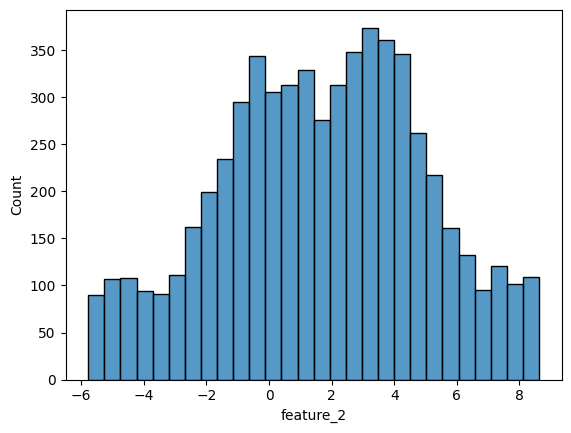

In [4]:
import seaborn as sns
sns.histplot(train_df['feature_2'])

<Axes: >

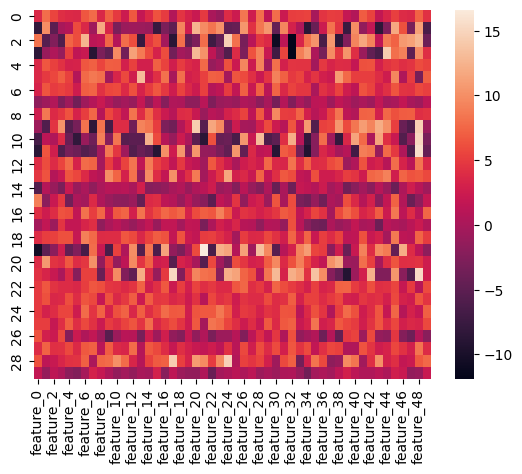

In [15]:
features = train_df.drop(['ID', 'Target'], axis=1)
sns.heatmap(features.head(30))

In [74]:
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

pca = PCA(0.95)
x_pca = pca.fit_transform(features)
x_inv = pca.inverse_transform(x_pca)
errs = np.linalg.norm(features-x_inv, axis=1)

In [75]:
np.sum(labels)

np.int64(3626)

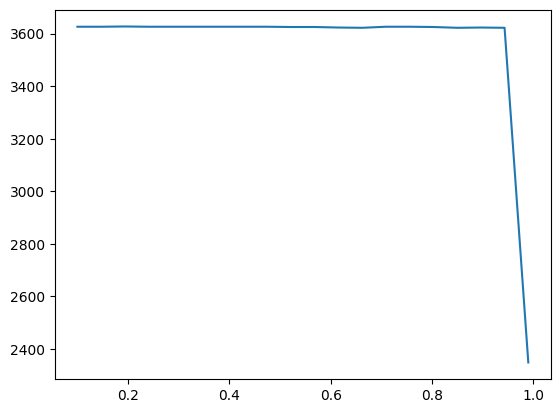

In [71]:
explained_ratios = np.linspace(0.1, 0.99, 20)
correct_labels = []
ids = []
for i in explained_ratios:
    pca = PCA(i)
    x_pca = pca.fit_transform(features)
    x_inv = pca.inverse_transform(x_pca)
    errs = np.linalg.norm(features-x_inv, axis=1)
    gmm = GaussianMixture(n_components=2, random_state=0)
    labels = gmm.fit_predict(errs.reshape(-1, 1))
    correct_labels.append(np.sum(labels))
    ids.append(pca.n_components_)

plt.plot(explained_ratios, correct_labels)
# plt.plot(explained_ratios, ids)

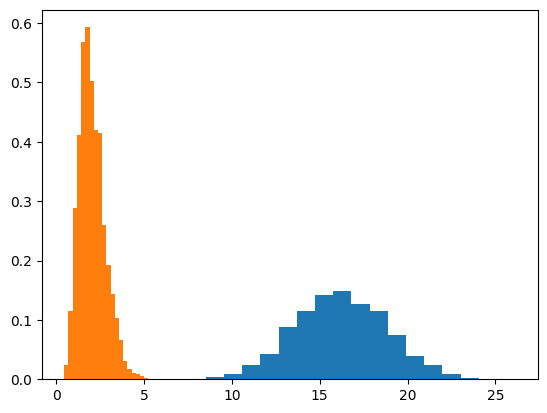

In [221]:
pca = PCA(0.9)
x_pca = pca.fit_transform(features)
x_inv = pca.inverse_transform(x_pca)
errs = np.linalg.norm(features-x_inv, axis=1)
gmm = GaussianMixture(n_components=2, random_state=0)
labels = gmm.fit_predict(errs.reshape(-1, 1))


for i in [0,1]:
    plt.hist(errs[labels==i], density=True, bins=20)

In [226]:
real_x = features.iloc[labels==1]
real_y = train_df['Target'].iloc[labels==1]
real_x

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49
0,3.679717,7.859348,5.495547,4.104880,3.707475,3.660929,6.528198,7.775889,3.652874,7.041674,...,0.575710,6.843685,5.470849,1.742942,3.463516,5.190351,3.869380,3.633768,7.197044,4.357440
4,3.646625,6.551672,5.360250,4.285500,3.030427,3.145273,6.507548,7.062654,5.560583,6.952077,...,1.829331,6.224670,6.281113,2.977234,4.467313,5.024911,4.048247,4.577488,5.930575,5.414766
5,3.606837,4.829819,5.670475,6.988936,5.362225,0.697872,7.607848,8.593644,8.003140,-0.387229,...,5.046082,5.053666,5.037016,3.940766,2.495544,9.478764,0.402268,5.016423,-3.291514,6.997318
6,3.162959,6.463585,5.019651,5.383042,4.832874,2.538605,6.967418,7.323427,4.249762,5.622732,...,1.368860,6.317172,5.455721,3.014762,4.243636,6.412635,4.441682,4.356216,5.734495,5.221595
7,-1.722880,-0.713797,0.578234,-2.722930,-0.745281,-3.614549,-0.668320,0.682478,2.197390,0.442437,...,-0.685734,0.126051,-0.677120,1.660216,-0.281312,0.063613,1.697784,-0.080909,-0.696076,1.300872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5992,-4.504694,1.189937,0.723331,-1.589349,0.826321,-3.011617,1.424946,2.931330,1.973864,0.053597,...,0.424129,-0.419968,-1.129422,2.449148,-1.154186,-1.664723,2.860102,1.363780,0.879713,1.404836
5993,5.115080,9.139876,3.049778,1.658113,4.760373,5.842372,4.127806,5.613586,-0.030241,9.332837,...,1.498666,5.239331,5.741576,3.082256,5.514034,2.710586,5.122425,3.531589,8.235659,3.454722
5997,3.197601,7.202918,4.727868,5.069308,5.157290,2.607833,5.533076,7.535665,3.955112,4.412959,...,2.327823,6.050649,6.822541,3.311042,5.761314,6.407502,4.544263,6.155864,2.314731,5.327457
5998,4.327531,7.925515,2.064351,2.459505,5.059683,5.337569,3.541615,4.147706,1.149844,8.950237,...,3.029844,4.223146,7.606691,5.093332,7.945368,3.059396,6.491105,6.189610,5.988441,4.716171


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler_x = StandardScaler()
train_x, val_x, train_y, val_y = train_test_split(real_x, real_y, test_size=0.1)
train_x = scaler_x.fit_transform(train_x)
val_x = scaler_x.transform(val_x)

: 

In [240]:
model = LinearRegression()
model.fit(train_x, train_y)
preds = model.predict(val_x)
print(mean_squared_error(val_y, preds))

3.89146900302583


<Axes: >

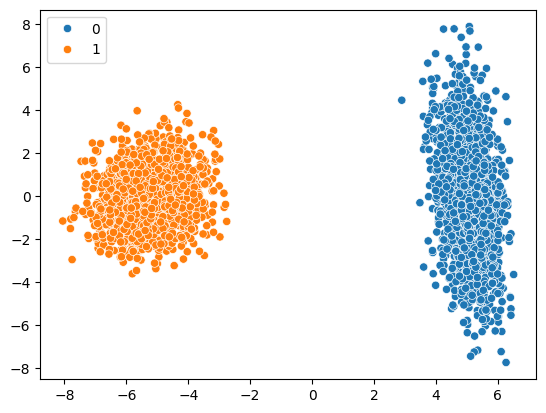

In [239]:
from sklearn.cluster import KMeans
km = KMeans(2)
pca = PCA(2)
pca_train_x = pca.fit_transform(train_x)
preds = km.fit_predict(train_x)
sns.scatterplot(x=pca_train_x[:, 0], y=pca_train_x[:, 1], hue=preds)

In [186]:
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
import optuna

# def objective(trial):
#     n_estimators = trial.suggest_int('n_estimators', 100, 1000, log=True)
#     max_depth = trial.suggest_int('max_depth', 2, 15)

#     model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth)

#     score = cross_val_score(model, train_x, train_y, cv=5, scoring="neg_mean_squared_error")
#     return -score

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=10, show_progress_bar=True)